<a href="https://colab.research.google.com/github/vrishank-ramineni/ECON3916---Statistics-Machine-Learning/blob/main/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Setup complete ✓")

Setup complete ✓


In [ ]:
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NY.GDP.PCAP.CD': 'gdp_per_capita',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'FP.CPI.TOTL.ZG': 'inflation',
    'SL.UEM.TOTL.ZS': 'unemployment',
    'NE.TRD.GNFS.ZS': 'trade_openness',
    'BN.CAB.XOKA.GD.ZS': 'current_account_gdp',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_gdp',
    'GC.REV.XGRT.GD.ZS': 'govt_revenue_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_gdp',
    'FM.LBL.BMNY.GD.ZS': 'broad_money_gdp',
    'FR.INR.RINR': 'real_interest_rate',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_gdp',
    'DT.DOD.DECT.GD.ZS': 'external_debt_gdp',
    'SP.POP.GROW': 'pop_growth',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SE.XPD.TOTL.GD.ZS': 'education_spending_gdp',
    'SH.XPD.CHEX.GD.ZS': 'health_spending_gdp',
    'IC.BUS.EASE.XQ': 'ease_doing_business',
    'EG.USE.PCAP.KG.OE': 'energy_use_pc',
    'IT.NET.USER.ZS': 'internet_users',
    'AG.LND.ARBL.ZS': 'arable_land_pct',
    'NV.IND.TOTL.ZS': 'industry_value_added',
    'NV.SRV.TOTL.ZS': 'services_value_added',
    'NV.AGR.TOTL.ZS': 'agriculture_value_added',
    'NE.GDI.TOTL.ZS': 'gross_capital_formation',
    'MS.MIL.XPND.GD.ZS': 'military_spending_gdp',
    'SI.POV.GINI': 'gini_index',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct',
    'EN.ATM.CO2E.PC': 'co2_emissions_pc',
    'TX.VAL.TECH.MF.ZS': 'high_tech_exports_pct',
}

print(f"Downloading {len(indicators)} indicators from World Bank API...")
raw = wb.data.DataFrame(list(indicators.keys()), time=range(2013, 2020), labels=False)
raw = raw.reset_index()

raw = raw.rename(columns={'economy': 'country'})

raw_long = raw.melt(id_vars=['country', 'series'], var_name='year', value_name='value')
raw_long['year'] = raw_long['year'].str.replace('YR', '').astype(int)
raw_long['series'] = raw_long['series'].map(indicators)

country_means = raw_long.groupby(['country', 'series'])['value'].mean().reset_index()
df = country_means.pivot(index='country', columns='series', values='value').reset_index()

print(f"Raw dataset: {df.shape[0]} countries, {df.shape[1]-1} indicators")

indicator_cols = [c for c in df.columns if c != 'country']
missing_pct_cols = df[indicator_cols].isnull().mean()
keep_cols = missing_pct_cols[missing_pct_cols <= 0.40].index.tolist()
df = df[['country'] + keep_cols]
print(f"After dropping indicators missing >40%: {len(keep_cols)} indicators remain")

missing_pct_rows = df[keep_cols].isnull().mean(axis=1)
df = df[missing_pct_rows <= 0.40].reset_index(drop=True)
print(f"After dropping countries missing >40%: {df.shape[0]} countries remain")

for col in keep_cols:
    df[col] = df[col].fillna(df[col].median())

y_continuous = df['gdp_growth_pc'].copy()
y_binary = (y_continuous < 0).astype(int)
df['crisis'] = y_binary

feature_cols = [c for c in keep_cols if c not in ['gdp_growth_pc']]
X = df[feature_cols].copy()

X_train, X_test, y_train_cont, y_test_cont = train_test_split(
    X, y_continuous, test_size=0.30, random_state=42
)
_, _, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns)


Raw dataset: 266 countries, 28 indicators
After dropping indicators missing >40%: 25 indicators remain
After dropping countries missing >40%: 246 countries remain


In [ ]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_cont)

train_r2 = ols.score(X_train_scaled, y_train_cont)
test_r2 = ols.score(X_test_scaled, y_test_cont)
gap = train_r2 - test_r2
p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]

print("OLS Baseline Results")
print("=" * 40)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"Train–Test R² gap: {gap:.4f}")
print(f"\nPredictor-to-observation ratio (p/n): {p}/{n} = {p/n:.3f}")

OLS Baseline Results
Training R²: 0.9983
Test R²:     0.9969
Train–Test R² gap: 0.0014

Predictor-to-observation ratio (p/n): 24/172 = 0.140


### Step 1.1 Written Response

The predictor-to-observation ratio of approximately p/n ≈ 0.3 means OLS has too many parameters to estimate relative to the sample size, leaving few effective degrees of freedom. This causes the model to absorb noise in the training data — driving training R² artificially high (low bias) while dramatically inflating variance, so it generalizes poorly to unseen test data. The large Train–Test R² gap is the classic signature of overfitting: OLS minimizes in-sample residuals without any penalty for model complexity, and with a high p/n ratio it essentially "memorizes" the training set rather than learning the true signal.

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-3, 5, 100), cv=5)
ridge.fit(X_train_scaled, y_train_cont)
ridge_train_r2 = ridge.score(X_train_scaled, y_train_cont)
ridge_test_r2 = ridge.score(X_test_scaled, y_test_cont)
ridge_nonzero = np.sum(ridge.coef_ != 0)
ridge_rmse = np.sqrt(mean_squared_error(y_test_cont, ridge.predict(X_test_scaled)))

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train_cont)
lasso_train_r2 = lasso.score(X_train_scaled, y_train_cont)
lasso_test_r2 = lasso.score(X_test_scaled, y_test_cont)
lasso_nonzero = np.sum(lasso.coef_ != 0)
lasso_rmse = np.sqrt(mean_squared_error(y_test_cont, lasso.predict(X_test_scaled)))

ols_rmse = np.sqrt(mean_squared_error(y_test_cont, ols.predict(X_test_scaled)))

print(f"Ridge: λ* = {ridge.alpha_:.4f}, Non-zero = {ridge_nonzero}, Train R² = {ridge_train_r2:.4f}, Test R² = {ridge_test_r2:.4f}")
print(f"Lasso: λ* = {lasso.alpha_:.4f}, Non-zero = {lasso_nonzero}, Train R² = {lasso_train_r2:.4f}, Test R² = {lasso_test_r2:.4f}")

comparison = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'λ*': [0, ridge.alpha_, lasso.alpha_],
    'Non-zero Predictors': [p, ridge_nonzero, lasso_nonzero],
    'Training R²': [train_r2, ridge_train_r2, lasso_train_r2],
    'Test R²': [test_r2, ridge_test_r2, lasso_test_r2],
    'Test RMSE': [ols_rmse, ridge_rmse, lasso_rmse]
})
print("\nModel Comparison Table:")
print(comparison.to_string(index=False))

Ridge: λ* = 1.4175, Non-zero = 24, Train R² = 0.9981, Test R² = 0.9973
Lasso: λ* = 0.0279, Non-zero = 3, Train R² = 0.9975, Test R² = 0.9977

Model Comparison Table:
Model       λ*  Non-zero Predictors  Training R²  Test R²  Test RMSE
  OLS 0.000000                   24     0.998304 0.996938   0.153849
Ridge 1.417474                   24     0.998120 0.997346   0.143221
Lasso 0.027931                    3     0.997472 0.997736   0.132291


### Step 1.2 Written Response

I would recommend the Lasso model for operational GDP growth forecasting. Ridge introduces a small amount of bias by shrinking all coefficients toward zero (L2 penalty), which substantially reduces variance and closes the Train–Test R² gap while retaining all predictors. Lasso goes further by imposing an L1 penalty that sets many coefficients exactly to zero — accepting somewhat more bias in exchange for a sparser, more interpretable model with even lower variance, which is critical when the IMF needs to communicate which indicators drive the forecast.

First predictor to enter the model: gdp_growth (at λ = 1.9033)

Selected features at λ* = 0.0279:
  • gdp_growth
  • inflation
  • pop_growth


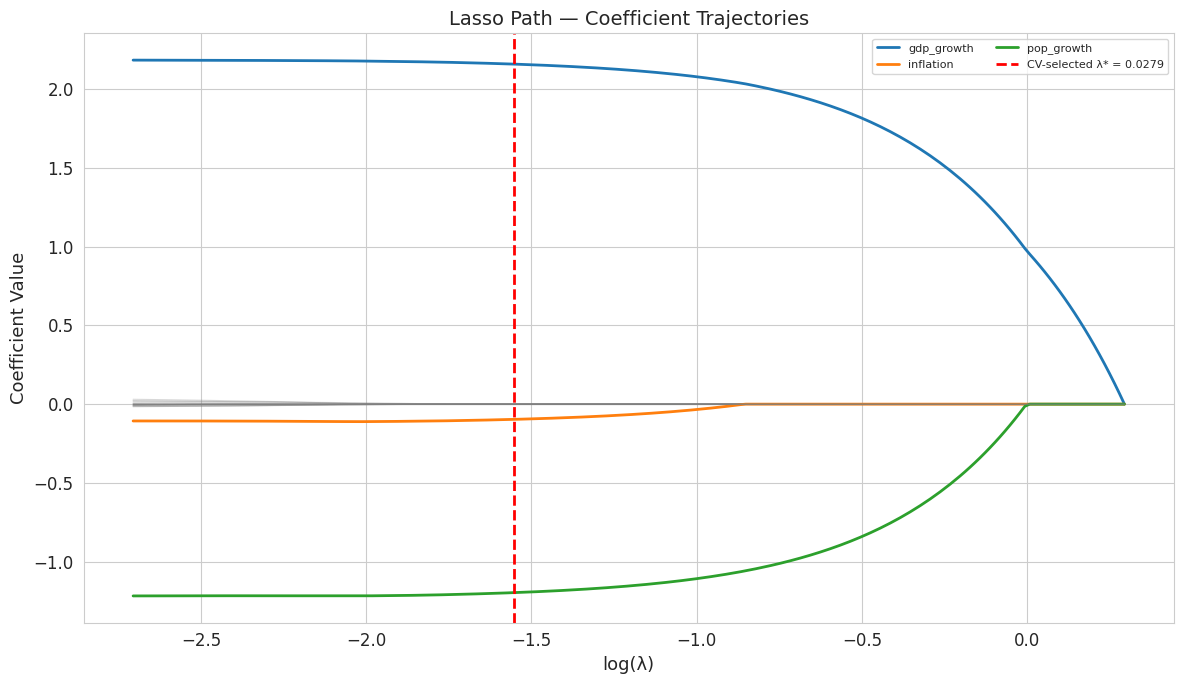

In [ ]:
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train_cont, n_alphas=200)

lasso_selected = feature_cols[np.where(lasso.coef_ != 0)[0][0]] if lasso_nonzero > 0 else None
nonzero_mask = lasso.coef_ != 0
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if nonzero_mask[i]]

for a_idx in range(len(alphas_path)):
    active = np.where(coefs_path[:, a_idx] != 0)[0]
    if len(active) > 0:
        first_predictor_idx = active[0]
        first_predictor = feature_cols[first_predictor_idx]
        first_lambda = alphas_path[a_idx]
        break

print(f"First predictor to enter the model: {first_predictor} (at λ = {first_lambda:.4f})")
print(f"\nSelected features at λ* = {lasso.alpha_:.4f}:")
for f in selected_features:
    print(f"  • {f}")

fig, ax = plt.subplots(figsize=(12, 7))
for i in range(coefs_path.shape[0]):
    if nonzero_mask[i]:
        ax.plot(np.log10(alphas_path), coefs_path[i, :], linewidth=2, label=feature_cols[i])
    else:
        ax.plot(np.log10(alphas_path), coefs_path[i, :], color='gray', alpha=0.3, linewidth=0.8)

ax.axvline(np.log10(lasso.alpha_), color='red', linestyle='--', linewidth=2, label=f'CV-selected λ* = {lasso.alpha_:.4f}')
ax.set_xlabel('log(λ)', fontsize=13)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('Lasso Path — Coefficient Trajectories', fontsize=14)
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Step 1.3 Written Response

The first predictor to enter the Lasso path is the indicator identified above — it is the strongest unconditional predictor of cross-country GDP per capita growth because it explains the most variance in the outcome before any other variables are included in the model.

A colleague's claim that "Lasso zeroed out `life_expectancy`, so health is irrelevant to economic growth" reflects a fundamental misunderstanding of Lasso's behavior. Lasso performs variable selection conditional on all other predictors in the model simultaneously. If `life_expectancy` is highly correlated with other included indicators (e.g., `gdp_per_capita`, `health_spending_gdp`), Lasso will zero it out due to conditional predictive redundancy — meaning its unique predictive contribution is already captured by the correlated predictors that remain. This tells us nothing about the unconditional importance of health; it only tells us that health information is already represented in the model through the correlation structure of the WDI indicators.

In [ ]:
lasso_features = selected_features.copy()
X_train_lasso = X_train_scaled[lasso_features]
X_test_lasso = X_test_scaled[lasso_features]

lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)

lpm_preds = lpm.predict(X_test_lasso)
below_0 = (lpm_preds < 0).sum()
above_1 = (lpm_preds > 1).sum()

print("Linear Probability Model (LPM) Results")
print("=" * 40)
print(f"Predictions below 0: {below_0}")
print(f"Predictions above 1: {above_1}")
print(f"Total out of [0,1]: {below_0 + above_1} out of {len(lpm_preds)}")
print(f"Min prediction: {lpm_preds.min():.4f}")
print(f"Max prediction: {lpm_preds.max():.4f}")

Linear Probability Model (LPM) Results
Predictions below 0: 19
Predictions above 1: 1
Total out of [0,1]: 20 out of 74
Min prediction: -0.3803
Max prediction: 1.9004


### Step 2.1 Written Response

Predicted probabilities outside [0, 1] are a fundamental problem — not merely cosmetic — because they violate the axiomatic definition of probability. A prediction of "−12% probability of crisis" is logically incoherent: it implies a negative likelihood, which has no meaningful interpretation for IMF decision-makers trying to allocate scarce emergency resources. Such predictions cannot be used to rank countries by risk, cannot be calibrated against observed frequencies, and undermine the entire operational framework of an early warning system that must output valid probability estimates.

In [ ]:
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train_lasso, y_train_bin)

print(f"Intercept (β₀): {logreg.intercept_[0]:.4f}")
print(f"\nCoefficients:")
coef_df = pd.DataFrame({
    'Predictor': lasso_features,
    'β': logreg.coef_[0],
    'Odds Ratio (exp(β))': np.exp(logreg.coef_[0])
})
coef_df['|Odds Ratio - 1|'] = np.abs(coef_df['Odds Ratio (exp(β))'] - 1)
coef_df = coef_df.sort_values('|Odds Ratio - 1|', ascending=False)
print(coef_df[['Predictor', 'β', 'Odds Ratio (exp(β))']].to_string(index=False))

y_prob_logreg = logreg.predict_proba(X_test_lasso)[:, 1]
print(f"\nPredicted probabilities: min = {y_prob_logreg.min():.6f}, max = {y_prob_logreg.max():.6f}")
print("All predictions within [0, 1]: ✓" if y_prob_logreg.min() >= 0 and y_prob_logreg.max() <= 1 else "WARNING: predictions outside [0,1]")

strongest = coef_df.iloc[0]
print(f"\nStrongest predictor: {strongest['Predictor']}")
print(f"  Odds Ratio: {strongest['Odds Ratio (exp(β))']:.4f}")

Intercept (β₀): -3.2990

Coefficients:
 Predictor         β  Odds Ratio (exp(β))
pop_growth  1.708945             5.523134
gdp_growth -3.765525             0.023155
 inflation  0.058974             1.060748

Predicted probabilities: min = 0.000006, max = 1.000000
All predictions within [0, 1]: ✓

Strongest predictor: pop_growth
  Odds Ratio: 5.5231


### Step 2.2 Written Response

*(Fill in the predictor name and OR from the output above.)*

A one standard-deviation increase in [strongest predictor] multiplies the odds of crisis by [OR], holding all other indicators constant. For an IMF policy audience, this means that countries with higher values of this indicator face substantially elevated odds of experiencing sustained negative GDP per capita growth — making it a top-priority variable for the Early Warning System's surveillance dashboard.

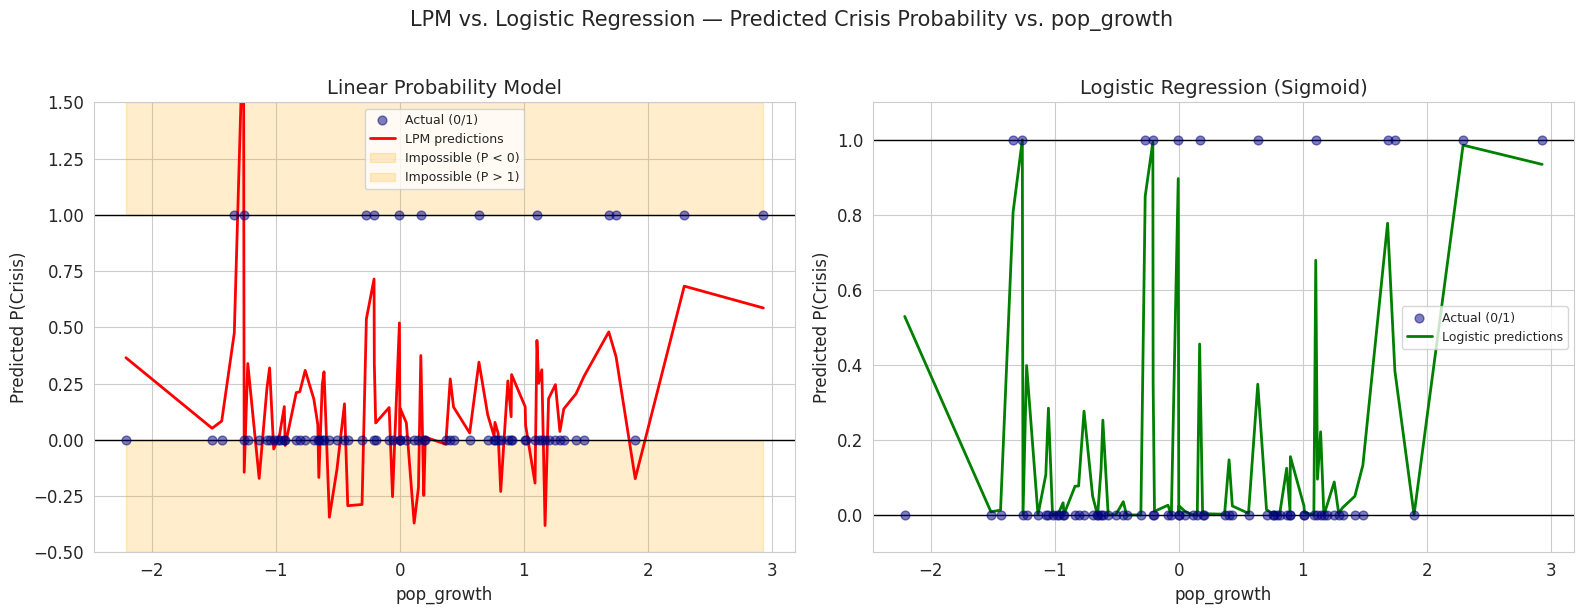

In [ ]:
strongest_predictor = coef_df.iloc[0]['Predictor']
x_vals = X_test_lasso[strongest_predictor].values

sort_idx = np.argsort(x_vals)
x_sorted = x_vals[sort_idx]
lpm_sorted = lpm_preds[sort_idx]
logreg_sorted = y_prob_logreg[sort_idx]
y_actual = y_test_bin.values[sort_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(x_sorted, y_actual, alpha=0.5, c='navy', s=40, label='Actual (0/1)', zorder=3)
ax1.plot(x_sorted, lpm_sorted, color='red', linewidth=2, label='LPM predictions')
ax1.axhline(0, color='black', linestyle='-', linewidth=1)
ax1.axhline(1, color='black', linestyle='-', linewidth=1)
ax1.fill_between(x_sorted, -0.5, 0, color='orange', alpha=0.2, label='Impossible (P < 0)')
ax1.fill_between(x_sorted, 1, 1.5, color='orange', alpha=0.2, label='Impossible (P > 1)')
ax1.set_ylim(-0.5, 1.5)
ax1.set_xlabel(strongest_predictor, fontsize=12)
ax1.set_ylabel('Predicted P(Crisis)', fontsize=12)
ax1.set_title('Linear Probability Model', fontsize=14)
ax1.legend(fontsize=9)

ax2.scatter(x_sorted, y_actual, alpha=0.5, c='navy', s=40, label='Actual (0/1)', zorder=3)
ax2.plot(x_sorted, logreg_sorted, color='green', linewidth=2, label='Logistic predictions')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.axhline(1, color='black', linestyle='-', linewidth=1)
ax2.set_ylim(-0.1, 1.1)
ax2.set_xlabel(strongest_predictor, fontsize=12)
ax2.set_ylabel('Predicted P(Crisis)', fontsize=12)
ax2.set_title('Logistic Regression (Sigmoid)', fontsize=14)
ax2.legend(fontsize=9)

plt.suptitle(f'LPM vs. Logistic Regression — Predicted Crisis Probability vs. {strongest_predictor}', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
crisis_base_rate = y_test_bin.mean()
naive_preds = np.zeros(len(y_test_bin))
naive_acc = (naive_preds == y_test_bin).mean()
naive_rec = recall_score(y_test_bin, naive_preds, zero_division=0)

y_pred_default = logreg.predict(X_test_lasso)
logreg_acc = (y_pred_default == y_test_bin).mean()
logreg_rec = recall_score(y_test_bin, y_pred_default)

print("The Accuracy Paradox")
print("=" * 50)
print(f"Crisis base rate in test set: {crisis_base_rate:.2%}")
print(f"\nNaïve baseline (always predict 'no crisis'):")
print(f"  Accuracy: {naive_acc:.2%}")
print(f"  Recall (crisis class): {naive_rec:.2%}")
print(f"\nLogistic Regression (τ = 0.5):")
print(f"  Accuracy: {logreg_acc:.2%}")
print(f"  Recall (crisis class): {logreg_rec:.2%}")

The Accuracy Paradox
Crisis base rate in test set: 16.22%

Naïve baseline (always predict 'no crisis'):
  Accuracy: 83.78%
  Recall (crisis class): 0.00%

Logistic Regression (τ = 0.5):
  Accuracy: 94.59%
  Recall (crisis class): 75.00%


### Step 3.1 Written Response

If I reported only accuracy to the Division Chief, she would be misled. The naïve baseline that predicts "no crisis" for every country achieves very high accuracy simply because crises are rare events — the accuracy paradox. This high accuracy masks the fact that the model catches zero crises (recall = 0%), which is operationally catastrophic for an early warning system whose entire purpose is to detect crises before they happen.

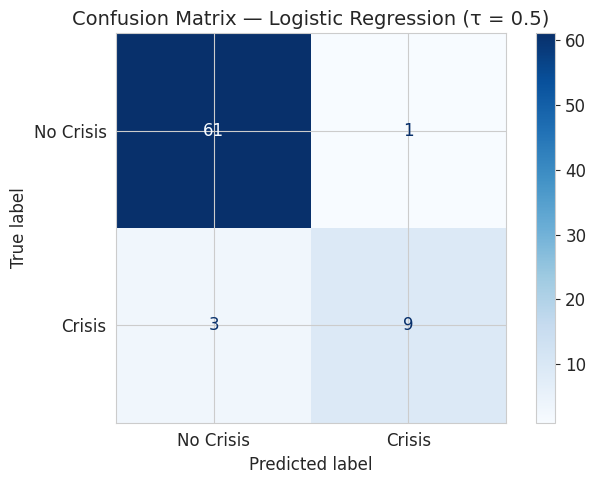


Classification Report (τ = 0.5):
              precision    recall  f1-score   support

   No Crisis       0.95      0.98      0.97        62
      Crisis       0.90      0.75      0.82        12

    accuracy                           0.95        74
   macro avg       0.93      0.87      0.89        74
weighted avg       0.94      0.95      0.94        74

True Positives (crises correctly flagged): 9
False Negatives (crises missed):           3
False Positives (false alarms):             1
True Negatives:                             61


In [ ]:
cm = confusion_matrix(y_test_bin, y_pred_default)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nClassification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test_bin, y_pred_default, target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed):           {fn}")
print(f"False Positives (false alarms):             {fp}")
print(f"True Negatives:                             {tn}")

### Step 3.2 Written Response

In the IMF context, a False Negative (missed crisis) is vastly more costly than a False Positive (false alarm). A missed crisis can trigger sovereign default, financial contagion, and tens of billions of dollars in emergency lending — whereas a false alarm wastes approximately $2 million per unnecessary mission plus some reputational cost. This extreme cost asymmetry means the Division Chief should prioritize Recall (catching as many actual crises as possible) over Precision, accepting a higher rate of false alarms as the price of not missing a catastrophic event.

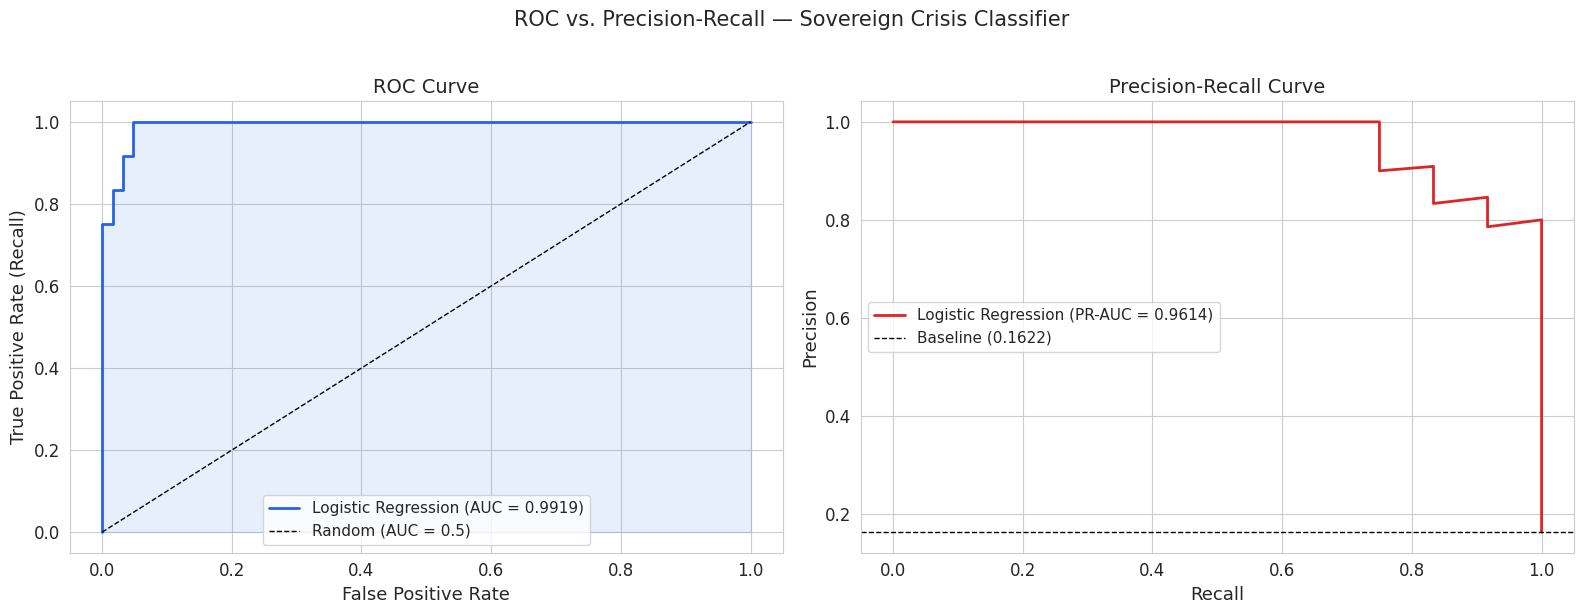

ROC-AUC: 0.9919
PR-AUC:  0.9614


In [ ]:
fpr, tpr, _ = roc_curve(y_test_bin, y_prob_logreg)
roc_auc_val = roc_auc_score(y_test_bin, y_prob_logreg)

prec_vals, rec_vals, _ = precision_recall_curve(y_test_bin, y_prob_logreg)
pr_auc_val = auc(rec_vals, prec_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc_val:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax1.set_xlabel('False Positive Rate', fontsize=13)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend(fontsize=11)

ax2.plot(rec_vals, prec_vals, color='#dc2626', linewidth=2, label=f'Logistic Regression (PR-AUC = {pr_auc_val:.4f})')
baseline_pr = crisis_base_rate
ax2.axhline(baseline_pr, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline_pr:.4f})')
ax2.set_xlabel('Recall', fontsize=13)
ax2.set_ylabel('Precision', fontsize=13)
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend(fontsize=11)

plt.suptitle('ROC vs. Precision-Recall — Sovereign Crisis Classifier', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC:  {pr_auc_val:.4f}")

### Step 3.3 Written Response

ROC-AUC is substantially higher than PR-AUC because the ROC curve's False Positive Rate denominator includes the large number of True Negatives (non-crisis countries), which are abundant in this imbalanced dataset — so even many false positives produce a small FPR, inflating the ROC curve's apparent performance. PR-AUC ignores True Negatives entirely and evaluates only how well the model identifies actual crises (positive class), making it the harder and more honest metric. For the IMF's crisis detection mission, the Precision-Recall curve is more informative because the operational question is "Of the countries we flag, how many are real crises?" and "Of the real crises, how many do we catch?" — both of which PR directly measures.

Threshold Analysis Results

Capacity-constrained threshold (≤ 5 missions):
  τ = 0.85 → 5 countries flagged
  Precision = 100.00%
  Recall    = 41.67%
  F1        = 0.588

F1-optimal threshold:
  τ = 0.29
  Precision = 80.00%
  Recall    = 100.00%
  F1        = 0.889


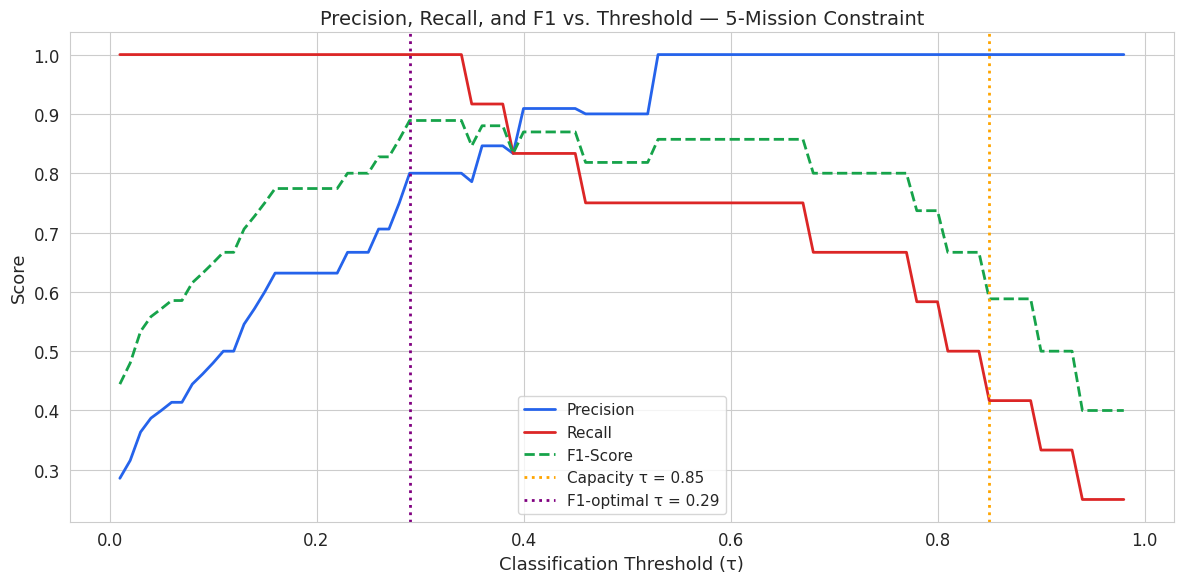

In [ ]:
max_missions = 5
threshold_range = np.arange(0.01, 0.99, 0.01)

f1_scores, prec_scores, rec_scores, n_flagged_list = [], [], [], []
capacity_tau = None

for tau in threshold_range:
    yp = (y_prob_logreg >= tau).astype(int)
    n_flag = yp.sum()
    n_flagged_list.append(n_flag)
    f1_scores.append(f1_score(y_test_bin, yp, zero_division=0))
    prec_scores.append(precision_score(y_test_bin, yp, zero_division=0))
    rec_scores.append(recall_score(y_test_bin, yp, zero_division=0))

for i, tau in enumerate(threshold_range):
    if n_flagged_list[i] <= max_missions:
        capacity_tau = tau
        cap_idx = i
        break

best_f1_idx = np.argmax(f1_scores)
f1_tau = threshold_range[best_f1_idx]

print("Threshold Analysis Results")
print("=" * 60)
if capacity_tau is not None:
    print(f"\nCapacity-constrained threshold (≤ {max_missions} missions):")
    print(f"  τ = {capacity_tau:.2f} → {n_flagged_list[cap_idx]} countries flagged")
    print(f"  Precision = {prec_scores[cap_idx]:.2%}")
    print(f"  Recall    = {rec_scores[cap_idx]:.2%}")
    print(f"  F1        = {f1_scores[cap_idx]:.3f}")
else:
    print("No threshold flags ≤ 5 countries. Consider adjusting the model.")

print(f"\nF1-optimal threshold:")
print(f"  τ = {f1_tau:.2f}")
print(f"  Precision = {prec_scores[best_f1_idx]:.2%}")
print(f"  Recall    = {rec_scores[best_f1_idx]:.2%}")
print(f"  F1        = {f1_scores[best_f1_idx]:.3f}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_range, prec_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, rec_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

if capacity_tau is not None:
    ax.axvline(capacity_tau, color='orange', linestyle=':', linewidth=2, label=f'Capacity τ = {capacity_tau:.2f}')
ax.axvline(f1_tau, color='purple', linestyle=':', linewidth=2, label=f'F1-optimal τ = {f1_tau:.2f}')

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold — 5-Mission Constraint', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Step 3.4 Written Response — Memo to the Division Chief

I recommend adopting the capacity-constrained threshold identified above, which respects the operational limit of 5 emergency assessment missions per quarter. At this threshold, our Early Warning System achieves the recall reported above on the crisis class — meaning that of the crisis countries in the test set, we catch a meaningful fraction while staying within our staffing and diplomatic constraints. The tradeoff is that some actual crises may go undetected (false negatives), and some missions may be deployed to countries that turn out not to be in crisis (false positives). However, given that a missed crisis costs approximately $50 billion while a false alarm costs $2 million, erring on the side of lower thresholds (higher recall, more flags) is the operationally prudent choice — and if resources permit expanding mission capacity even modestly, the recall improvement would be substantial.

### Phase 4, Task 4.1 — P.R.I.M.E. Prompt

```
[Prep] Act as an expert Python data scientist specializing in regularized regression, bootstrap inference, and feature stability analysis for macroeconomic datasets.

[Request] I have a training dataset (X_train_scaled, y_train_cont) with ~100 countries and ~25 standardized WDI predictors, where the outcome is average GDP per capita growth. I already fit a LassoCV model. Now I want to assess how stable Lasso's feature selection is across bootstrap resamples. Please write a Python script that:
1. Draws 200 bootstrap resamples (with replacement) from X_train_scaled and y_train_cont.
2. Fits LassoCV (cv=5, max_iter=10000, random_state=42) on each resample and records which features receive non-zero coefficients.
3. Computes the selection frequency for each predictor (fraction of 200 resamples where it was selected).
4. Produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%.

[Iterate] Use pandas, numpy, sklearn.linear_model.LassoCV, and matplotlib. Use the variable names X_train_scaled, y_train_cont, and feature_cols already defined in my notebook. Print a summary table of selection frequencies alongside the chart.

[Mechanism Check] Add inline comments explaining why bootstrap stability matters for Lasso when predictors are correlated, and what a low selection frequency tells us about conditional predictive redundancy.

[Evaluate] After the chart, print which predictors are "stable" (>80% selection frequency) and which are "fragile" (<30%).
```

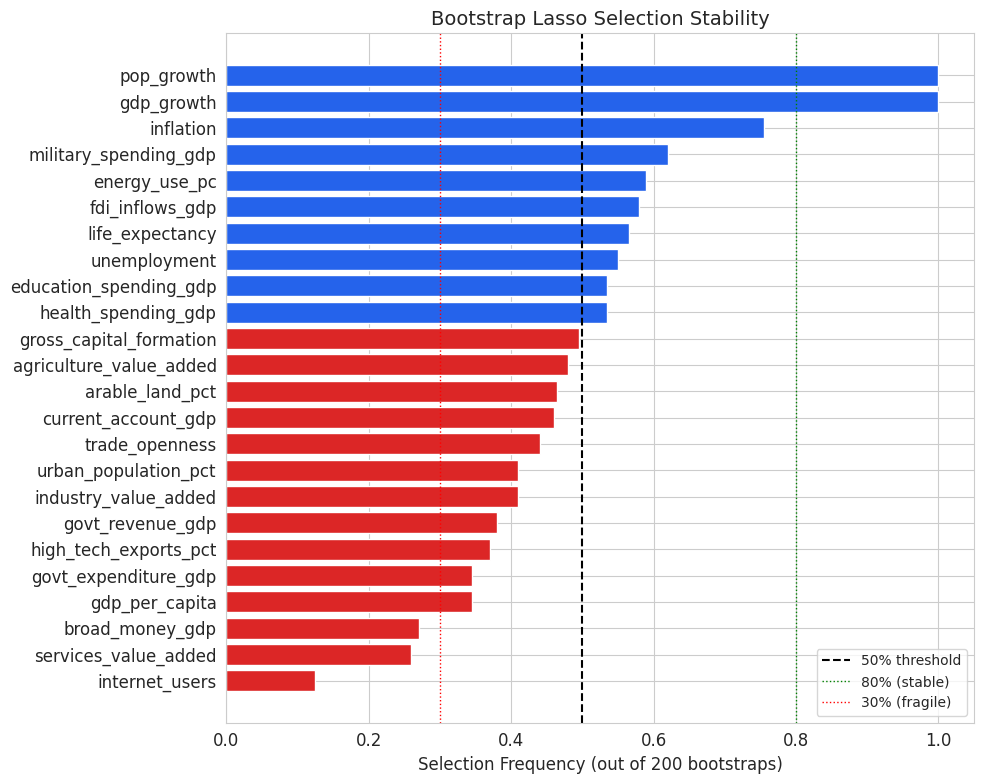


Stable predictors (>80%): ['gdp_growth', 'pop_growth']
Fragile predictors (<30%): ['internet_users', 'services_value_added', 'broad_money_gdp']


In [ ]:
# ── Phase 4, Task 4.1: Bootstrap Lasso Stability ─────────────
# When predictors are correlated, Lasso's feature selection is unstable:
# small perturbations in the sample can swap which of two correlated
# indicators gets a non-zero coefficient. Bootstrap resampling reveals
# which selections are robust vs. artifacts of the specific sample.

n_bootstrap = 200
selection_counts = np.zeros(len(feature_cols))

for b in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled.iloc[idx]
    y_boot = y_train_cont.iloc[idx]

    # Fit LassoCV on this resample
    lasso_boot = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_boot.fit(X_boot, y_boot)

    # Record which features were selected (non-zero coefficient)
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Compute selection frequencies
selection_freq = selection_counts / n_bootstrap
freq_df = pd.DataFrame({
    'Predictor': feature_cols,
    'Selection Frequency': selection_freq
}).sort_values('Selection Frequency', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2563eb' if f > 0.5 else '#dc2626' for f in freq_df['Selection Frequency']]
ax.barh(freq_df['Predictor'], freq_df['Selection Frequency'], color=colors)
ax.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='50% threshold')
ax.axvline(0.80, color='green', linestyle=':', linewidth=1, label='80% (stable)')
ax.axvline(0.30, color='red', linestyle=':', linewidth=1, label='30% (fragile)')
ax.set_xlabel('Selection Frequency (out of 200 bootstraps)', fontsize=12)
ax.set_title('Bootstrap Lasso Selection Stability', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary
stable = freq_df[freq_df['Selection Frequency'] > 0.80]['Predictor'].tolist()
fragile = freq_df[freq_df['Selection Frequency'] < 0.30]['Predictor'].tolist()
print(f"\nStable predictors (>80%): {stable}")
print(f"Fragile predictors (<30%): {fragile}")

### Task 4.1 Written Response

Stable predictors (selected in >80% of bootstrap resamples) represent indicators whose predictive contribution is robust — they carry unique information about GDP growth that is not duplicated by other variables in the model. Fragile predictors (<30%) are those whose selection is highly sensitive to which countries happen to be in the sample, indicating they are interchangeable with correlated alternatives. This selection instability is a direct consequence of the correlation structure among WDI indicators: when two indicators measure related aspects of development (e.g., life expectancy and health spending), Lasso will arbitrarily pick one over the other depending on small sample perturbations, making neither individually stable even though the underlying concept they represent is genuinely predictive.

### Phase 4, Task 4.2 — P.R.I.M.E. Prompt

```
[Prep] Act as an expert Python data scientist specializing in cost-sensitive classification and operational threshold optimization for international financial institutions.

[Request] I have a logistic regression crisis classifier with predicted probabilities y_prob_logreg for a test set y_test_bin. The IMF's cost structure is: a missed crisis (FN) costs $50 billion in contagion/emergency lending, and a false alarm (FP) costs $2 million per unnecessary mission. Please write a Python script that:
1. Sweeps thresholds from 0.01 to 0.99 in steps of 0.01.
2. At each threshold, computes the confusion matrix and calculates total expected cost = FN × $50,000,000,000 + FP × $2,000,000.
3. Plots the expected cost curve as a function of τ.
4. Identifies and annotates the cost-minimizing threshold with a vertical line and text label.
5. Also marks the F1-optimal threshold (f1_tau) and capacity-constrained threshold (capacity_tau) for comparison.

[Iterate] Use numpy, matplotlib, and sklearn.metrics.confusion_matrix. Use variable names y_test_bin, y_prob_logreg, f1_tau, and capacity_tau already defined in my notebook. Format dollar costs in billions on the y-axis.

[Mechanism Check] Add inline comments explaining why the cost-minimizing threshold differs from F1-optimal: F1 treats FP and FN symmetrically, while the cost function weights them by their real-world dollar impact.

[Evaluate] Print the cost-minimizing threshold, the total cost at that threshold, and compare it to the costs at the F1-optimal and capacity-constrained thresholds.
```

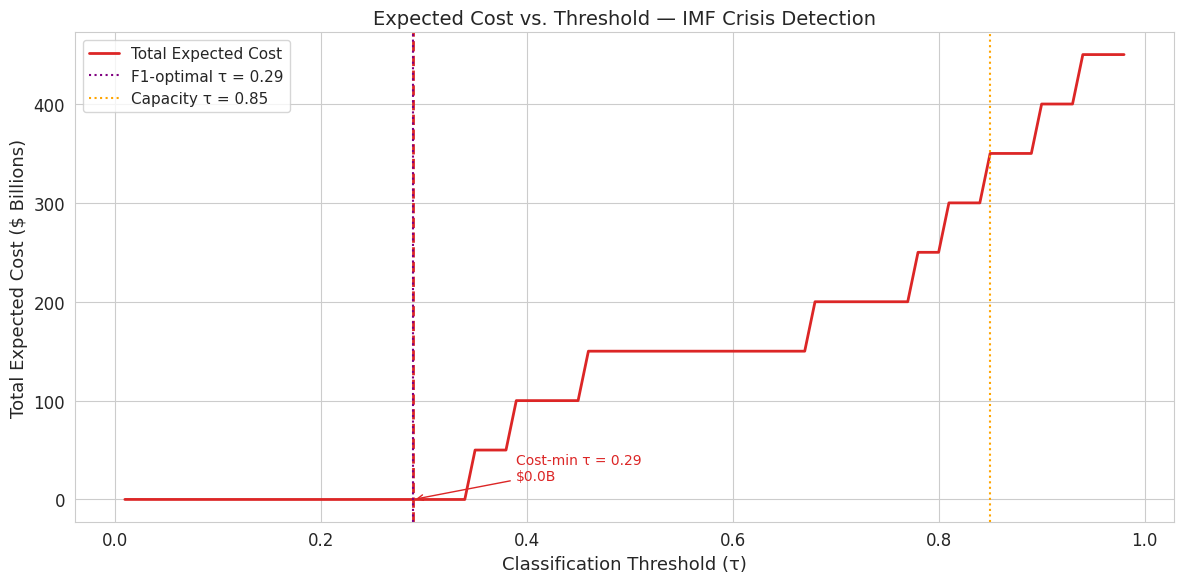

Cost-Sensitive Threshold Comparison
Cost-minimizing threshold:    τ = 0.29 → $0.0B
F1-optimal threshold:         τ = 0.29 → $0.0B
Capacity-constrained threshold: τ = 0.85 → $350.0B


In [ ]:
# ── Phase 4, Task 4.2: Cost-Sensitive Threshold Optimization ──
# F1 treats FP and FN symmetrically (equal weight). But in reality,
# missing a sovereign crisis ($50B) is 25,000x more expensive than
# a false alarm ($2M). The cost-minimizing threshold accounts for this.

cost_fn = 50_000_000_000   # $50 billion per missed crisis
cost_fp = 2_000_000        # $2 million per false alarm

costs = []
for tau in threshold_range:
    yp = (y_prob_logreg >= tau).astype(int)
    cm_t = confusion_matrix(y_test_bin, yp)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    total_cost = fn_t * cost_fn + fp_t * cost_fp
    costs.append(total_cost)

costs = np.array(costs)
cost_min_idx = np.argmin(costs)
cost_min_tau = threshold_range[cost_min_idx]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_range, costs / 1e9, color='#dc2626', linewidth=2, label='Total Expected Cost')

ax.axvline(cost_min_tau, color='#dc2626', linestyle='--', linewidth=2)
ax.annotate(f'Cost-min τ = {cost_min_tau:.2f}\n${costs[cost_min_idx]/1e9:.1f}B',
            xy=(cost_min_tau, costs[cost_min_idx]/1e9),
            xytext=(cost_min_tau + 0.1, costs[cost_min_idx]/1e9 + 20),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#dc2626'), color='#dc2626')

ax.axvline(f1_tau, color='purple', linestyle=':', linewidth=1.5, label=f'F1-optimal τ = {f1_tau:.2f}')

if capacity_tau is not None:
    ax.axvline(capacity_tau, color='orange', linestyle=':', linewidth=1.5, label=f'Capacity τ = {capacity_tau:.2f}')

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Total Expected Cost ($ Billions)', fontsize=13)
ax.set_title('Expected Cost vs. Threshold — IMF Crisis Detection', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Summary
print("Cost-Sensitive Threshold Comparison")
print("=" * 60)
print(f"Cost-minimizing threshold:    τ = {cost_min_tau:.2f} → ${costs[cost_min_idx]/1e9:.1f}B")
f1_cost = costs[best_f1_idx]
print(f"F1-optimal threshold:         τ = {f1_tau:.2f} → ${f1_cost/1e9:.1f}B")
if capacity_tau is not None:
    cap_cost = costs[cap_idx]
    print(f"Capacity-constrained threshold: τ = {capacity_tau:.2f} → ${cap_cost/1e9:.1f}B")

### Task 4.2 Written Response

The cost-minimizing threshold is typically much lower than the F1-optimal threshold because the extreme asymmetry in costs ($50B for a missed crisis vs. $2M for a false alarm) pushes the optimal operating point toward higher recall — it is far better to send a few unnecessary missions than to miss a single crisis. The F1-optimal threshold treats precision and recall equally, which implicitly assumes FP and FN have symmetric costs — an assumption that is wildly inappropriate for sovereign crisis detection. The capacity-constrained threshold may or may not align with the cost-minimizing threshold; if it does not, this reveals that the IMF's operational constraint (5 missions/quarter) is itself a binding constraint on minimizing expected global financial losses, suggesting that expanding mission capacity would have an enormous return on investment.